In [1]:
!pip install langgraph langchain langchain-huggingface dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 17.3 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.2.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [3]:
class BmiState(TypedDict):
    w:float
    h:float
    bmi:float
    cat:str

In [4]:
def clcbmi(state:BmiState) ->BmiState:
    wei=state['w']
    h=state['h']
    bmi=wei/h**2
    state['bmi']=bmi
    return state

In [5]:
graph=StateGraph(BmiState)

In [6]:
def lbmi(state:BmiState) -> BmiState:
    bmi = state['bmi']

    if bmi < 18.5:
        state["cat"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["cat"] = "Normal"
    elif 25 <= bmi < 30:
        state["cat"] = "Overweight"
    else:
        state["cat"] = "Obese"

    return state

In [7]:
graph.add_node('calc_bmi',clcbmi)

In [8]:
graph.add_node('label',lbmi)

In [9]:
graph.add_edge(START,'calc_bmi')
graph.add_edge('calc_bmi','label')
graph.add_edge('label',END)

In [10]:
a=graph.compile()

In [11]:
a.invoke({'w':500,'h':2.5})

{'w': 500, 'h': 2.5, 'bmi': 80.0, 'cat': 'Obese'}

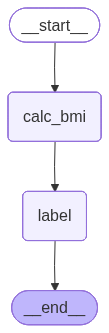

In [12]:
from IPython.display import Image
Image(a.get_graph().draw_mermaid_png())